In [55]:
# we need it in all codes
import numpy as np 
import math

import scipy.sparse
from scipy.sparse import csr_matrix
# see functions here
# https://numpy.org/doc/stable/reference/generated/numpy.exp.html
# https://numpy.org/doc/stable/reference/routines.array-manipulation.html
#

# basic vector and matrix operations
# general principle: we do not have to write functions for everything
# moreover, built-in vectorized operations are rather fast


# EIGENVALUES IN SIMPLE CASES

In [56]:
# compute the eigenvaues and the corresponding eigenvectors of the diagonal matrix
# with the diagonal [1, -3, 4, 0]

w, v = np.linalg.eig(np.diag((1, -3, 4, 0)))
# Here we obtain the eigenvalues (collected into a vector)
# and the corresponding eigenvectors. These are column vectors 
# and are collected into a matrix.

for i in np.arange(4):
    print(f"Eigenvalue {i+1} = {w[i]} with eigenvector = {v[:,i]}")

Eigenvalue 1 = (1+0j) with eigenvector = [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
Eigenvalue 2 = (-3+0j) with eigenvector = [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
Eigenvalue 3 = (4+0j) with eigenvector = [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
Eigenvalue 4 = 0j with eigenvector = [0.+0.j 0.+0.j 0.+0.j 1.+0.j]


In [57]:
# Verify in a simple example that the eigenvectors of any symmetric 
# matrix are orthogonal to each other.

A = np.random.rand(10,10)

# This is OK, but how could you produce a random symmetric matrix? A_sym = 1/2 (A + A.T) is called the symmetric part of A

A_sym = 0.5 * (A + np.transpose(A))

w, v_orig = np.linalg.eig(A_sym)

print("Eigenvalues of A_sym:")
print(w)
print(f"The eigenvectors are stored as columns in a matrix, with shape: {v_orig.shape}")


print("Running test to check if they are orthogonal:")
print(v.real@np.transpose(v).real) # use .real to only show the real part.

Eigenvalues of A_sym:
[ 5.06821946+0.j -1.11430662+0.j  0.97961875+0.j  0.62109041+0.j
 -0.62217649+0.j  0.40960866+0.j -0.26766683+0.j  0.22616404+0.j
 -0.10460795+0.j  0.05074732+0.j]
The eigenvectors are stored as columns in a matrix, with shape: (10, 10)
Running test to check if they are orthogonal:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


In [58]:
# verify also that the eigenvalues of the inverse matrix are 
# the reciprocial of the original eigenvalues
Sinv = np.linalg.inv(A_sym)
winv, vinv = np.linalg.eig(Sinv)

# Be careful, the order can be changed
# Sort the eigenvalues of the first one and the second one, too.

print("The eigenvalues of the inverse of the symmetric part of A are:")
print(np.sort(winv).real)
print("These eigenvalues coincide with  the inverse of the eigenvalues of A_sym :")
print(np.sort(1/w).real)

The eigenvalues of the inverse of the symmetric part of A are:
[-9.5595027  -3.73598776 -1.607261   -0.89741906  0.19730795  1.02080529
  1.61007155  2.44135466  4.42156945 19.70547592]
These eigenvalues coincide with  the inverse of the eigenvalues of A_sym :
[-9.5595027  -3.73598776 -1.607261   -0.89741906  0.19730795  1.02080529
  1.61007155  2.44135466  4.42156945 19.70547592]


In [59]:
# Consider the following permutation matrix 
#    [ 0 1 2 3 4 5 6 7] 
# -> [ 3 7 4 6 0 1 5 2]
P = np.zeros((8,8))
P[1,5] = 1 
P[5,6] = 1 
P[6,3] = 1
P[3,0] = 1
P[0,4] = 1
P[4,2] = 1
P[2,7] = 1 
P[7,1] = 1
print(P)


# Verify experimentally that the absolute value of its 
# eigenvalues are all one.
w_P, v = np.linalg.eig(P)
print("Are the absolute value of the eigenvalues of P all 1?")
print(abs(w_P))
print("Yes!")

[[0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]]
Are the absolute value of the eigenvalues of P all 1?
[1. 1. 1. 1. 1. 1. 1. 1.]
Yes!


In [63]:
#What happens if we multiply P 8 times?
from numpy.linalg import matrix_power
matrix_power(P,8) - np.eye(8)

array([[0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.]])

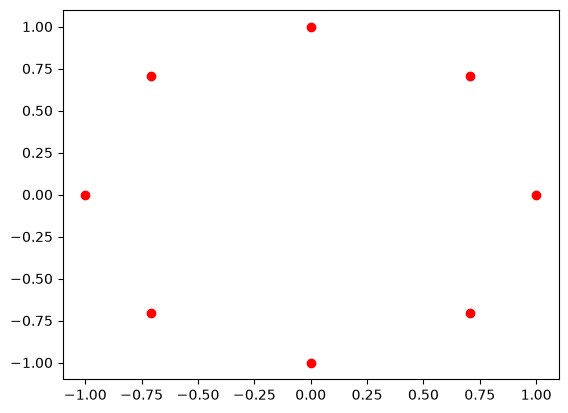

In [61]:
import matplotlib.pyplot as plt
import numpy as np

# Print them
X = [x.real for x in w_P]
Y = [x.imag for x in w_P]
plt.scatter(X,Y, color='red')
plt.show()
#We can see that the eigenvalue of permutations lie in the unit circle in C!
#If we permute with P enough times we will go back to the beginning, i.e.,
# there exists some k such that P^k = I, then P x = \lambda x and
# P^k x = lambda ^k x imply lambda^k = 1 which are the k-th roots of unity.

# In our case:
#    [ 0 1 2 3 4 5 6 7] 
# -> [ 3 7 4 6 0 1 5 2]
#can be written as a cycle of size 8
#(0 3 6 5 1 7 2 4 ) " 0 goes to 3 which goes to 6..."
#Then, if we permute this numbers 8 times we go back to the beginning, i.e, k = 8
#There will be 8 eigenvalues, all the 8th roots of unity

# THE POWER METHOD - A simple code

In [ ]:
# Find eigenvalue with the largest magnitude and the corresponding 
# eigenvector of the matrix A_sym.

#.1 Choose an initial guess, hoping its not orthogonal
#to the eigenvector we are seeking
#.2 Perform the iteration v^{n+1} = A v^n and then normalize it
v_pow = np.ones((10,)) 
for j in range(15):
    v_pow =  A_sym @ v_pow / np.linalg.norm(v_pow)
v_pow = v_pow/np.linalg.norm(v_pow)
print(f"The exact error of our method (eigenvectors) is {np.linalg.norm(v_pow-v_orig[:,0])}")

#To obtain the corresponding eigenvalue, use Rayleigh quotient:
R_q = np.dot(A_sym @ v_pow, v_pow)


# The dominant eigenvalue obtained with np.linalg.eig is w[0]
print(f"The exact error (eigenvalues) is  {abs(R_q - w[0])}")



The exact error of our method (eigenvectors) is 2.0
The exact error (eigenvalues) is  5.329070518200751e-15
